# Data Acquisition

In [2]:
!pip install -U kagglehub


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import kagglehub

In [4]:
# Download latest version
path = kagglehub.dataset_download("sebastianwillmann/beverage-sales")

In [5]:
print(path)

/home/ubuntu/.cache/kagglehub/datasets/sebastianwillmann/beverage-sales/versions/1


In [6]:
import os, shutil

print("files:")
for f in os.listdir(path):
    print(f)


files:
synthetic_beverage_sales_data.csv


In [7]:
src = os.path.join(path, "synthetic_beverage_sales_data.csv")
dst = "synthetic_beverage_sales_data.csv"
shutil.copy(src, dst)
print("copied to:", dst)


copied to: synthetic_beverage_sales_data.csv


In [8]:
!mv synthetic_beverage_sales_data.csv beverage_sales.csv

The above cells import the dataset directly from Kaggle, confirm the working directory path, and simplify the name of the file.

### Dataset description and initial exploration
This dataset, chosen from Kaggle, provides a detailed simulation of wholesale beverage sales, designed to reflect realistic patterns in the industry.
It includes Order ID, Customer ID, Customer Type, Product, Category, Unit Price, Quantity, Discount, Total Price, Region and the Order Date.
The dataset contains approximately 8.9 million records over a period of three years from 2021-2023. After filtering for just 2023, the dataset contains approximately 2.9 million rows.
The row count verification is done in the data wrangling section.

### Dataset Selection Rationale
The dataset meets the requirement of 250,000 rows. 
It contains transactional data which can easily be organized in a dimensional format with dimensions such as customers, products and dates.
It is well-suited for answering business questions about seasonal demand, regional product performance and discount strategies.

# Data Wrangling

In [9]:
!csvcut -n beverage_sales.csv

  1: Order_ID
  2: Customer_ID
  3: Customer_Type
  4: Product
  5: Category
  6: Unit_Price
  7: Quantity
  8: Discount
  9: Total_Price
 10: Region
 11: Order_Date


The csvcut command provides a preview of the columns available in the csv file of the data set. 

In [10]:
!xsv stats -s "Order_Date" beverage_sales.csv

field,type,sum,min,max,min_length,max_length,mean,stddev
Order_Date,Unicode,,2021-01-01,2023-12-30,10,10,,


This code displays the format and other details of the Order_Date column.

In [11]:
!csvgrep -c Order_Date -r '^2023-' beverage_sales.csv > beverage_2023.csv

This filters the dataset to only include orders that occured in the year 2023.

In [12]:
!wc -l beverage_sales.csv

8999911 beverage_sales.csv


In [13]:
!wc -l beverage_2023.csv

2994658 beverage_2023.csv


This code confirms that the filtered data for the year 2023 is about one third the size of the original dataset, which included orders for a period of three years. (Both of the above counts include the header rows. The goal in this particular step is not precision, rather confirming the data set was correctly filtered to include only one out of three years of data.)

In [14]:
import duckdb

In [15]:
con = duckdb.connect("project.duckdb")

The above code will connect to a persistent database to store the data in-memory. When using this, the rest of the code using duck DB will use "con.sql" instead of "duckdb.sql".

In [16]:
# create table from csv
con.sql("""
    DROP TABLE IF EXISTS beverage;
    CREATE TABLE beverage AS
    SELECT * FROM read_csv_auto('beverage_2023.csv', HEADER=TRUE);
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [17]:
con.sql("SELECT * FROM beverage LIMIT 10").df()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23
5,ORD2,CUS2847,B2C,Sauvignon Blanc,Alcoholic Beverages,9.09,2,0.00,18.18,Schleswig-Holstein,2023-03-16
6,ORD4,CUS2275,B2C,Mountain Dew,Soft Drinks,0.99,11,0.00,10.89,Bayern,2023-11-05
7,ORD5,CUS7919,B2B,Hohes C Orange,Juices,1.52,8,0.05,11.55,Bayern,2023-08-05
8,ORD5,CUS7919,B2B,Red Bull,Soft Drinks,2.13,16,0.05,32.38,Bayern,2023-08-05
9,ORD5,CUS7919,B2B,Chardonnay,Alcoholic Beverages,6.45,3,0.05,18.38,Bayern,2023-08-05


The two cells above create a data structure (table) using the file containing data previously filtered, then display a preview to confirm success.

In [18]:
# define columns and the data type they contain, ensure only valid data is added
con.sql("""
    CREATE OR REPLACE TABLE star_beverage AS
    SELECT
        CAST(Order_ID      AS VARCHAR)  AS order_id,
        CAST(Customer_ID   AS VARCHAR)  AS customer_id,
        CAST(Customer_Type AS VARCHAR)  AS customer_type,
        CAST(Product       AS VARCHAR)  AS product,
        CAST(Category      AS VARCHAR)  AS category,
        CAST(Region        AS VARCHAR)  AS region,
        CAST(Order_Date    AS DATE)     AS order_date,
        CAST(Quantity      AS INTEGER)  AS quantity,
        CAST(Unit_Price    AS DOUBLE)   AS unit_price,
        CAST(Discount      AS DOUBLE)   AS discount,
        CAST(Total_Price   AS DOUBLE)   AS total_price
    FROM beverage
    WHERE
        Product      IS NOT NULL
        AND Category IS NOT NULL
        AND Customer_ID IS NOT NULL
        AND Region      IS NOT NULL
        AND Order_Date  IS NOT NULL
        AND Quantity    IS NOT NULL AND Quantity    > 0
        AND Unit_Price  IS NOT NULL AND Unit_Price  > 0
        AND Total_Price IS NOT NULL AND Total_Price > 0;
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [19]:
con.sql("SELECT * FROM star_beverage LIMIT 10").df()

,order_id,customer_id,customer_type,product,category,region,order_date,quantity,unit_price,discount,total_price
0,ORD1,CUS1496,B2B,Vio Wasser,Water,Baden-Württemberg,2023-08-23,53,1.66,0.10,79.18
1,ORD1,CUS1496,B2B,Evian,Water,Baden-Württemberg,2023-08-23,90,1.56,0.10,126.36
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,Baden-Württemberg,2023-08-23,73,1.17,0.05,81.14
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,Baden-Württemberg,2023-08-23,59,3.22,0.10,170.98
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,Baden-Württemberg,2023-08-23,35,0.87,0.10,27.40
5,ORD2,CUS2847,B2C,Sauvignon Blanc,Alcoholic Beverages,Schleswig-Holstein,2023-03-16,2,9.09,0.00,18.18
6,ORD4,CUS2275,B2C,Mountain Dew,Soft Drinks,Bayern,2023-11-05,11,0.99,0.00,10.89
7,ORD5,CUS7919,B2B,Hohes C Orange,Juices,Bayern,2023-08-05,8,1.52,0.05,11.55
8,ORD5,CUS7919,B2B,Red Bull,Soft Drinks,Bayern,2023-08-05,16,2.13,0.05,32.38
9,ORD5,CUS7919,B2B,Chardonnay,Alcoholic Beverages,Bayern,2023-08-05,3,6.45,0.05,18.38


The two cells above use the table previously created to define the data types for each column, remove any null or invalid values, then display a preview to confirm success in cleaning the data.

The following cells will create the fact and dimension tables and display previews to confirm success, illustrated below with the star schema.

In [20]:
## Date Dimension
con.sql("""
DROP TABLE IF EXISTS date;

CREATE TABLE date AS
SELECT
    ROW_NUMBER() OVER (ORDER BY order_date) AS date_key,  -- surrogate key
    order_date                                      AS order_date,
    EXTRACT(YEAR  FROM order_date)                  AS year,
    EXTRACT(MONTH FROM order_date)                  AS month,
    EXTRACT(DAY   FROM order_date)                  AS day,
    CASE
        WHEN STRFTIME(order_date, '%w') IN ('0', '6') THEN TRUE
        ELSE FALSE
    END                                             AS is_weekend,
    CASE
        WHEN STRFTIME(order_date, '%w') NOT IN ('0', '6') THEN TRUE
        ELSE FALSE
    END                                             AS is_weekday
FROM (
    SELECT DISTINCT order_date
    FROM star_beverage
    WHERE order_date IS NOT NULL
);
""")

In [21]:
con.sql("SELECT * FROM date LIMIT 5").df()

,date_key,order_date,year,month,day,is_weekend,is_weekday
0,1,2023-01-01,2023,1,1,True,False
1,2,2023-01-02,2023,1,2,False,True
2,3,2023-01-03,2023,1,3,False,True
3,4,2023-01-04,2023,1,4,False,True
4,5,2023-01-05,2023,1,5,False,True


This code expands the original Order_Date column to add columns for year, month, day. This will be necessary later when analyzing seasonal trends in orders.

In [22]:
## Customer Dimension
con.sql("""
DROP TABLE IF EXISTS customer;

CREATE TABLE customer AS
SELECT
    ROW_NUMBER() OVER (ORDER BY customer_id) AS customer_key,  -- surrogate key
    customer_id                              AS customer_id,
    customer_type                            AS customer_type,
    region                                   AS region
FROM (
    SELECT DISTINCT customer_id, customer_type, region
    FROM star_beverage
    WHERE customer_id   IS NOT NULL
      AND customer_type IS NOT NULL
      AND region        IS NOT NULL
);
""")

In [23]:
con.sql("SELECT * FROM customer LIMIT 5").df()

,customer_key,customer_id,customer_type,region
0,1,CUS1,B2C,Mecklenburg-Vorpommern
1,2,CUS10,B2C,Saarland
2,3,CUS100,B2C,Bayern
3,4,CUS1000,B2B,Thüringen
4,5,CUS10000,B2B,Sachsen


In [24]:
## Product Dimension
con.sql("""
DROP TABLE IF EXISTS product;

CREATE TABLE product AS
SELECT
    ROW_NUMBER() OVER (ORDER BY product, category) AS product_key,
    product                                        AS product,
    category                                       AS category
FROM (
    SELECT DISTINCT product, category
    FROM star_beverage
    WHERE product      IS NOT NULL
      AND category     IS NOT NULL
);
""")

In [25]:
con.sql("SELECT * FROM product LIMIT 5").df()

,product_key,product,category
0,1,Apollinaris,Water
1,2,Augustiner,Alcoholic Beverages
2,3,Bacardi,Alcoholic Beverages
3,4,Beck's,Alcoholic Beverages
4,5,Chardonnay,Alcoholic Beverages


In [26]:
# add surrogate keys for each dimension
con.sql("""
    ALTER TABLE star_beverage ADD COLUMN date_key     INTEGER;
    ALTER TABLE star_beverage ADD COLUMN customer_key INTEGER;
    ALTER TABLE star_beverage ADD COLUMN product_key  INTEGER;
""")

This code adds columns for each of the three surrogate keys.
                       
The following three cells create relationships between the surrogate keys in the dimension tables and the foreign keys in the fact table.

In [27]:
# create relationship between fact table and date dimension table, matching keys
con.sql("""
    UPDATE star_beverage AS f
    SET date_key = d.date_key
    FROM date AS d
    WHERE f.order_date = d.order_date;
""")

In [28]:
# create relationship between fact table and customer dimension table, matching keys
con.sql("""
    UPDATE star_beverage AS f
    SET customer_key = c.customer_key
    FROM customer AS c
    WHERE f.customer_id = c.customer_id;
""")

In [29]:
# create relationship between fact table and product dimension table, matching keys
con.sql("""
    UPDATE star_beverage AS f
    SET product_key = p.product_key
    FROM product AS p
    WHERE f.product = p.product
      AND f.category = p.category;
""")

In [30]:
# remove unneccary columns from fact table
con.sql("""
    ALTER TABLE star_beverage DROP COLUMN order_date;
    ALTER TABLE star_beverage DROP COLUMN customer_id;
    ALTER TABLE star_beverage DROP COLUMN customer_type;
    ALTER TABLE star_beverage DROP COLUMN product;
    ALTER TABLE star_beverage DROP COLUMN category;
    ALTER TABLE star_beverage DROP COLUMN region;
""")

In [31]:
con.sql("SELECT * FROM star_beverage LIMIT 5").df()

,order_id,quantity,unit_price,discount,total_price,date_key,customer_key,product_key
0,ORD1,53,1.66,0.10,79.18,235,554,43
1,ORD1,90,1.56,0.10,126.36,235,554,10
2,ORD1,73,1.17,0.05,81.14,235,554,39
3,ORD1,59,3.22,0.10,170.98,235,554,30
4,ORD1,35,0.87,0.10,27.40,235,554,13


The code in the two cells above remove the columns unneccessary in the fact table and display a preview to confirm success.

In [32]:
# display star schema
from IPython.display import Image
Image(url="https://github.com/96195hsu-create/data_final_project/blob/main/Star%20Schema.jpg?raw=true")

### Dimensional Model
Grain: Each row in star_beverage represents one order line: a quantity of a given product sold to a specific customer on a specific date.

The Order ID is considered as a degenerate dimension in the fact table as no other descriptive attributes are provided about Orders.

Region was included in the Customer Dimension as the region refers to the region of the customer.


# Analytical Questions & Visualization

## Q1) How does the popularity of each category change by month? Are there clear seasonal peaks?

In [33]:
## I define “most popular” as the highest total quantity sold
con.sql("""
WITH monthly_category_sales AS (
    SELECT
        d.year,
        d.month,
        p.category,
        CAST(SUM(f.quantity)    AS BIGINT) AS total_quantity
    FROM star_beverage AS f
    JOIN product       AS p ON f.product_key = p.product_key
    JOIN date          AS d ON f.date_key    = d.date_key
    GROUP BY d.year, d.month, p.category
),
-- Aggregate total quantity per month and category

ranked AS (
    SELECT
        year,
        month,
        category,
        total_quantity,
        RANK() OVER (
            PARTITION BY month
            ORDER BY total_quantity DESC
        ) AS rnk
    FROM monthly_category_sales
)
-- Rank categories within each month by total quantity (1 = highest)

SELECT
    year,
    month,
    category,
    total_quantity,
    rnk
FROM ranked
ORDER BY month, rnk;
""").df()
## One row per month and per category with rank

## I use ranking to find how each category performs within every month by sales volume
## First aggregates total quantity for each month and category, then ranks categories within each month by volume
## Showing monthly ranking by category, based on total quantity sold

,year,month,category,total_quantity,rnk
0,2023,1,Juices,1483860,1
1,2023,1,Soft Drinks,1475013,2
2,2023,1,Water,1471990,3
3,2023,1,Alcoholic Beverages,1467777,4
4,2023,2,Water,1344555,1
5,2023,2,Juices,1342804,2
6,2023,2,Alcoholic Beverages,1342423,3
7,2023,2,Soft Drinks,1330034,4
8,2023,3,Soft Drinks,1489334,1
9,2023,3,Water,1484087,2


In [34]:
# Import visualization previously created. Code was removed to improve length of notebook and notebook performance.
from IPython.display import Image
Image(url="https://github.com/96195hsu-create/data_final_project/blob/main/monthly_popularity_2023_.png?raw=true")

### Analysis:
Overall, category shares are very stable. Each beverage stays around 24–26% of total sales, with only small changes in who ranks first. Therefore, there is no strong seasonal peak where one category suddenly dominates.
* Although the gap versus other categories is only a few percentage points, Soft drinks are the most consistently strong category; even when they are not the first, they stay very close to the top.
* Alcoholic beverages show a modest bump from August to October and reach first place in August. This timing overlaps with traditional beer festival season in Germany, so a reasonable business hypothesis is that local festivals and related promotions slightly boost alcoholic drink demand during this period.
* The volume drop in February is mostly a calendar effect; February has fewer days, so total monthly sales are lower even if daily demand is stable. For this month, it is better to compare average daily sales rather than raw monthly totals. I also switched to analysing average daily sales per month instead of total monthly sales to verify this hypothesis.

### Business takeaway:

* Supply & inventory planning <br />
Because category shares are very stable, the business can plan almost flat production and inventory across the year instead of building large seasonal buffers.
Soft drinks can be treated as the baseline volume driver: keep a steady safety stock and capacity for this category, and only make small adjustments month to month.
February should not be treated as a true demand slump; the lower total volume mainly comes from fewer calendar days. For capacity planning, use average daily sales so that February isn’t under-stocked or misclassified as off-season.
* Promotion & campaign design <br />
Since no category suddenly dominates, large, risky “all-in” seasonal bets are unnecessary.
The modest uplift of Alcoholic Beverages in Aug–Oct gives a targeted opportunity:
Run festival-themed promotions (e.g., beer-festival campaigns, bundles, limited editions).
Slightly increase shelf space and stock for alcoholic drinks in late summer / early autumn while keeping other categories at normal levels.
For the rest of the year, promotions can focus more on share-shifting (stealing share between categories or brands) rather than chasing a big natural seasonal wave.

In [35]:
## I switch from monthly totals to average daily quantity to avoid the “February has fewer days” bias
con.sql("""
WITH daily_category AS (
    SELECT
        d.year,
        d.month,
        d.date_key,
        p.category,
        SUM(f.quantity) AS daily_quantity
    FROM star_beverage AS f
    JOIN product AS p ON f.product_key = p.product_key
    JOIN date    AS d ON f.date_key   = d.date_key
    GROUP BY d.year, d.month, d.date_key, p.category
),
-- Compute total quantity per day and category

with_index AS (
    SELECT
        year,
        month,
        category,
        ROUND(AVG(daily_quantity), 2) AS avg_daily_quantity,
        AVG(daily_quantity) / AVG(AVG(daily_quantity)) OVER (PARTITION BY year, category)  AS qty_season_index,
        RANK() OVER (
            PARTITION BY year, month
            ORDER BY AVG(daily_quantity) DESC
        ) AS rnk_avg_daily_qty
    FROM daily_category
    GROUP BY year, month, category
)
-- Compute avg daily quantity per month, seasonal index vs yearly average, and monthly rank

SELECT
    year,
    month,
    category,
    avg_daily_quantity,
    qty_season_index,
    rnk_avg_daily_qty
FROM with_index
ORDER BY year, month, rnk_avg_daily_qty;
""").df()
## Return one row per year, month, and category with avg daily quantity, index, and rank

## Control for different month lengths and capture true demand intensity by category
## For each month and category, its average daily sales, seasonal index vs the yearly daily average, and rank within that month

,year,month,category,avg_daily_quantity,qty_season_index,rnk_avg_daily_qty
0,2023,1,Juices,47866.45,1.006965,1
1,2023,1,Soft Drinks,47581.06,0.998384,2
2,2023,1,Water,47483.55,0.997727,3
3,2023,1,Alcoholic Beverages,47347.65,0.995298,4
4,2023,2,Water,48019.82,1.008996,1
5,2023,2,Juices,47957.29,1.008876,2
6,2023,2,Alcoholic Beverages,47943.68,1.007827,3
7,2023,2,Soft Drinks,47501.21,0.996709,4
8,2023,3,Soft Drinks,48043.03,1.008078,1
9,2023,3,Water,47873.77,1.005927,2


In [36]:
# Import visualization previously created. Code was removed to improve length of notebook and notebook performance.
from IPython.display import Image
Image(url="https://github.com/96195hsu-create/data_final_project/blob/main/popularity_.png?raw=true")

When I first looked at monthly totals, February showed an obvious dip in volume. However, this mainly comes from the calendar, not from real demand: February simply has fewer days than other months. If we compare raw monthly totals, any month with fewer days will always look weaker, even if people buy the same amount per day.
To remove this calendar bias, I switched to analysing average daily sales per month instead of total monthly sales.

In [37]:
# I define “most popular” as the highest total quantity sold

con.sql("""
SELECT
    p.category,
    CAST(SUM(f.quantity)    AS BIGINT) AS total_quantity,
    CAST(SUM(f.total_price) AS BIGINT) AS total_revenue
FROM star_beverage AS f
JOIN product       AS p ON f.product_key = p.product_key
GROUP BY p.category
ORDER BY total_quantity DESC;
""").df()

## Sum the total quantity for each category, then order by total quantity to show which category has the highest total quantity sold
## I also sum the total revenue to check whether any difference between popularity and revenue

,category,total_quantity,total_revenue
0,Soft Drinks,17348325,28445448
1,Water,17321801,16751868
2,Alcoholic Beverages,17315303,310978585
3,Juices,17302762,45598835


In [38]:
# Import visualization previously created. Code was removed to improve length of notebook and notebook performance.
from IPython.display import Image
Image(url="https://github.com/96195hsu-create/data_final_project/blob/main/popularity_2023.png?raw=true")

Using total quantity sold, Soft Drinks are the most popular category, but the difference is tiny.
All four categories each account for about a quarter of total sales, so the overall demand is very balanced, with no clear dominant category, Soft Drinks only slightly outperform the others.

## Q2) Which of the categories are most popular, and are any of those being discounted?

In [39]:
# create dataframe for later visualization comparing most popular and associated discounts.
# aggregating total quantity sold for each category
# identify which products are popular by volume
# calculate average discount per category
# identifies whether higher selling categories are being discounted more or less
# then we join popularity data with discount data


overlap_df = con.sql("""
WITH category_sales AS (
    SELECT
        p.category,
        SUM(f.quantity) AS total_quantity
    FROM star_beverage AS f
    JOIN product       AS p ON f.product_key = p.product_key
    GROUP BY p.category
),
category_discounts AS (
    SELECT
        p.category,
        AVG(f.discount) AS avg_discount_pct,
        SUM(f.quantity) AS total_quantity_discounted
    FROM star_beverage AS f
    JOIN product       AS p ON f.product_key = p.product_key
    WHERE f.discount IS NOT NULL AND f.discount > 0
    GROUP BY p.category
),
combined AS (
    SELECT
        cs.category,
        cs.total_quantity,
        cd.avg_discount_pct,
        cd.total_quantity_discounted
    FROM category_sales     AS cs
    JOIN category_discounts AS cd
        ON cs.category = cd.category
)
SELECT
    category,
    total_quantity,
    avg_discount_pct,
    total_quantity_discounted
FROM combined
ORDER BY total_quantity DESC, avg_discount_pct DESC;
""").df()

overlap_df

,category,total_quantity,avg_discount_pct,total_quantity_discounted
0,Soft Drinks,17348325.0,0.083519,13498404.0
1,Water,17321801.0,0.083516,13472755.0
2,Alcoholic Beverages,17315303.0,0.083486,13453147.0
3,Juices,17302762.0,0.083487,13446858.0


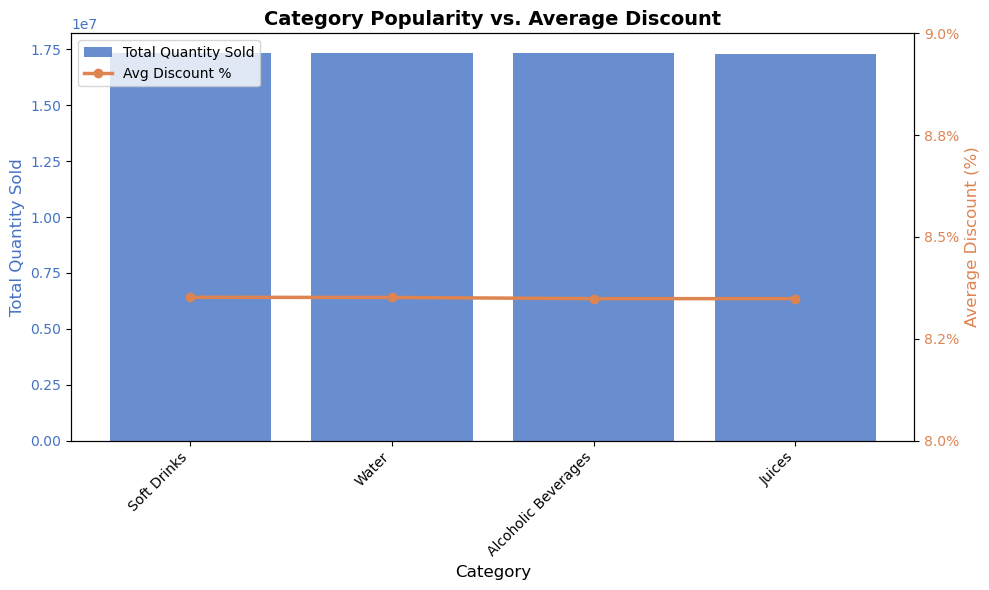

In [40]:
# use above data frame to create visualization
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Sort by popularity (total quantity)
plot_df = overlap_df.sort_values("total_quantity", ascending=False).copy()

# ensuring avg_discount_pct is a float so the line chart works
plot_df["avg_discount_pct"] = plot_df["avg_discount_pct"].astype(float)

x = np.arange(len(plot_df))

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for popularity (total quantity sold)
ax1.bar(x, plot_df["total_quantity"],
        color="#4472C4", alpha=0.8, label="Total Quantity Sold")

ax1.set_xlabel("Category", fontsize=12)
ax1.set_ylabel("Total Quantity Sold", color="#4472C4", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#4472C4")

ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["category"], rotation=45, ha="right")

# Line chart for avg discount
ax2 = ax1.twinx()
ax2.plot(x, plot_df["avg_discount_pct"],
         color="#DD8452", marker="o", linewidth=2.5, label="Avg Discount %")

ax2.set_ylabel("Average Discount (%)", color="#DD8452", fontsize=12)
ax2.tick_params(axis="y", labelcolor="#DD8452")

# y-axis between 8% and 9%
ax2.set_ylim(0.08, 0.09)
ax2.set_yticks([0.08, 0.0825, 0.085, 0.0875, 0.09])
ax2.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))

plt.title("Category Popularity vs. Average Discount", fontsize=14, weight="bold")

#combining the legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left")

plt.tight_layout()
plt.show()


### Findings
All 4 categories are being discounted with an average discount of 8.35%. The discount percentage is nearly identical which means there is a uniform discounting strategy rather than one targeted to specific product categories. The company may consider adjusting discount levels temporarily to determine the impact on the sales volume. For example, it could look to decrease discounts among more popular products or increase it on less popular products to see the customer response.


## Q3) Which product is the top seller by quantity in each region?

In [41]:
# identify the product that has the highest quantity sold in each region.
# aggregate total quantity and total revenue in each region.
# used cast to to convert quantity to integer.
# rounded total revenue to 2 decimal places.
# ranked the products to identify the top selling product in each region. The product having the highest quanity would have rank = 1.
# partition restarts ranking for each region.
# return only rank = 1 to get the top selling product in each region.
# ordered the results by total quantity in descending order.

top_products_by_region = con.sql("""
WITH region_sales AS (
    SELECT
        c.region,
        p.product,
        CAST(SUM(f.quantity) AS INT)    AS total_quantity, 
        ROUND(SUM(f.total_price), 2) AS total_revenue
    FROM star_beverage AS f
    JOIN customer      AS c ON f.customer_key = c.customer_key
    JOIN product       AS p ON f.product_key  = p.product_key
    GROUP BY c.region, p.product
),
ranked AS (
    SELECT
        region,
        product,
        total_quantity,
        total_revenue,
        RANK() OVER (
            PARTITION BY region 
            ORDER BY total_quantity DESC
        ) AS rnk
    FROM region_sales
) 

SELECT
    region,
    product AS top_product, 
    total_quantity,
    total_revenue
FROM ranked 
WHERE rnk = 1
ORDER BY total_quantity desc;
""").df() # saving it as a dataframe for the visualization

top_products_by_region

,region,top_product,total_quantity,total_revenue
0,Berlin,Fritz-Kola,268308,625497.29
1,Bremen,Beck's,257281,377175.55
2,Hamburg,Fritz-Kola,215890,502067.44
3,Hessen,Hohes C Orange,202629,402306.74
4,Thüringen,Hohes C Orange,194820,384903.46
5,Niedersachsen,Hohes C Orange,187623,370835.75
6,Rheinland-Pfalz,Vittel,178149,116870.22
7,Saarland,Hohes C Orange,169532,337702.69
8,Mecklenburg-Vorpommern,Tomato Juice,161919,446211.74
9,Nordrhein-Westfalen,Fanta,158035,167986.05


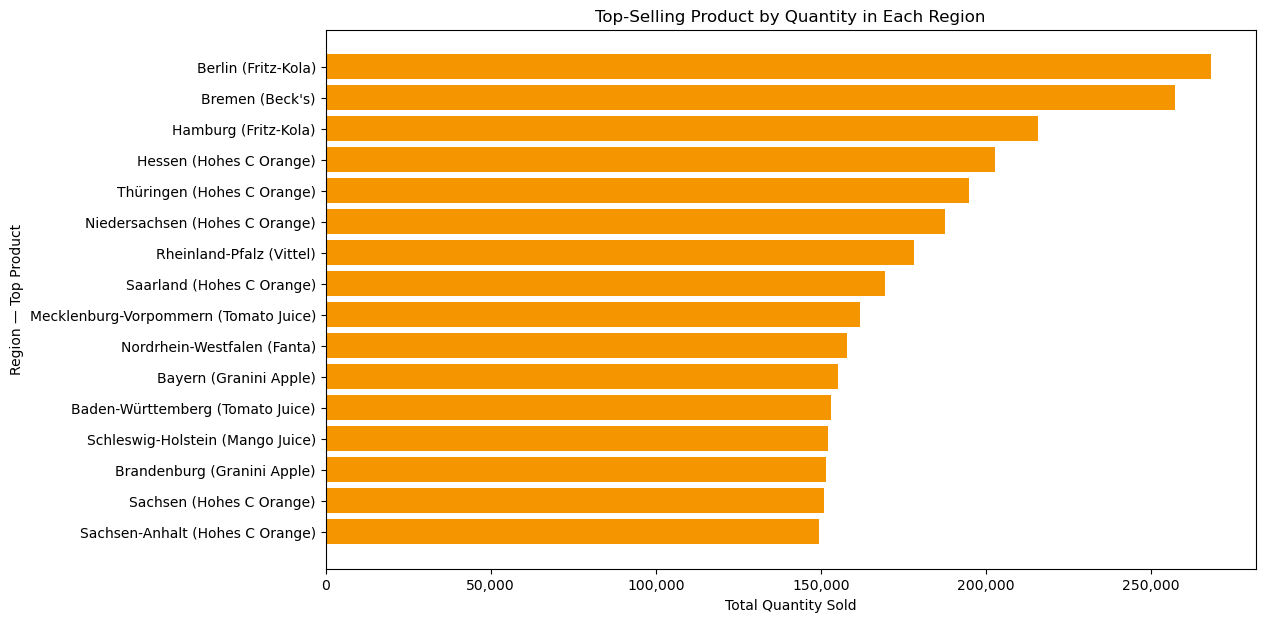

In [42]:
# create visualization

# define barh_df
barh_df = top_products_by_region.copy()

# Create a combined label: "Region (Product)"
barh_df["label"] = barh_df["region"] + " (" + barh_df["top_product"] + ")"

# Sort by total_quantity 
barh_df = barh_df.sort_values("total_quantity")

fig, ax = plt.subplots(figsize=(12, 7))

# Horizontal bar chart
ax.barh(barh_df["label"], barh_df["total_quantity"], color="#f59601")


ax.set_xlabel("Total Quantity Sold") # Label x-axis
ax.set_ylabel("Region — Top Product") # Label y-axis
ax.set_title("Top-Selling Product by Quantity in Each Region") # set title for the plot

from matplotlib.ticker import StrMethodFormatter 
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) # format x-axis numbers

plt.show()

In [43]:
# just for reference, identifying the most popular product by revenue in each region.
# aggregate total quantity and total revenue in each region.
# used cast to to convert quantity to integer.
# rounded total revenue to 2 decimal places.
# ranked the products to identify the most popular product by revenue in each region. 
# partition restarts ranking for each region.
# return only rank = 1 to get the top selling product by revenue in each region.
# ordered the results by total revenue in descending order.

top_products_by_region_revenue = con.sql("""
WITH region_sales AS (
    SELECT
        c.region,
        p.product,
        CAST(SUM(f.quantity) AS INT)    AS total_quantity, 
        ROUND(SUM(f.total_price), 2) AS total_revenue
    FROM star_beverage AS f
    JOIN customer      AS c ON f.customer_key = c.customer_key
    JOIN product       AS p ON f.product_key  = p.product_key
    GROUP BY c.region, p.product
),
ranked AS (
    SELECT
        region,
        product,
        total_quantity,
        total_revenue,
        RANK() OVER (
            PARTITION BY region 
            ORDER BY total_revenue DESC
        ) AS rnk
    FROM region_sales
) 

SELECT
    region,
    product AS top_product, 
    total_quantity,
    total_revenue
FROM ranked 
WHERE rnk = 1
ORDER BY total_revenue desc;
""")

top_products_by_region_revenue

┌────────────────────────┬────────────────┬────────────────┬───────────────┐
│         region         │  top_product   │ total_quantity │ total_revenue │
│        varchar         │    varchar     │     int32      │    double     │
├────────────────────────┼────────────────┼────────────────┼───────────────┤
│ Hessen                 │ Veuve Clicquot │          59729 │    4705423.21 │
│ Hamburg                │ Veuve Clicquot │          60779 │    4685005.42 │
│ Saarland               │ Veuve Clicquot │          58391 │    4588736.57 │
│ Rheinland-Pfalz        │ Veuve Clicquot │          57652 │    4548729.32 │
│ Thüringen              │ Veuve Clicquot │          57746 │    4499965.33 │
│ Mecklenburg-Vorpommern │ Veuve Clicquot │          57305 │    4479399.96 │
│ Bayern                 │ Veuve Clicquot │          54800 │    4400901.29 │
│ Baden-Württemberg      │ Veuve Clicquot │          54292 │    4277807.98 │
│ Niedersachsen          │ Veuve Clicquot │          53240 │    4252693.05 │

### Findings:
The visualization above shows the quantity of the top-selling product in each region, showing that product preferences differ across the country.

Hohes C Orange is the most popular product by quantity in 6 regions. 

Fritz-Kola dominates in 2 regions, namely, Berlin and Hamburg. Berlin being a major city has the highest sales volume amounting to approximately 268,308 units.

Other regions show a more even distribution of demand, indicated by the lower quantity of their top-selling product.

According to our findings, it is more appropriate to calculate the most popular product by quantity rather than total revenue. If measured by total revenue, Veuve Clicquot appears as the most popular product in each region (as shown in the output above) due to its higher price rather than higher unit sales. Due to the high unit price for Veuve Clicquot, ranking by revenue provides confounding results regarding popularity.

From a business perspective, the company should implement a region-based product strategy rather than a uniform national approach given the diverse demand patterns across regions. Promotions should be tailored to product popularity in each region. This can increase sales and improve the company's revenue.

## Q4) Among B2B sales, are larger orders from repeat customers? What about BTC sales?
Initial results seemed odd, such as more than 52 orders from one customer in one year - more than one a week. Additional preliminary count queries were added here to better place later analytical queries in context.

In [44]:
# First, determine how many customers exist of each type in the dataset
con.sql("""
    SELECT
        c.customer_type,
        COUNT(DISTINCT c.customer_id) AS customer_count
    FROM customer AS c
    GROUP BY c.customer_type
    ORDER BY customer_count DESC;
""")

┌───────────────┬────────────────┐
│ customer_type │ customer_count │
│    varchar    │     int64      │
├───────────────┼────────────────┤
│ B2C           │           6437 │
│ B2B           │           3563 │
└───────────────┴────────────────┘

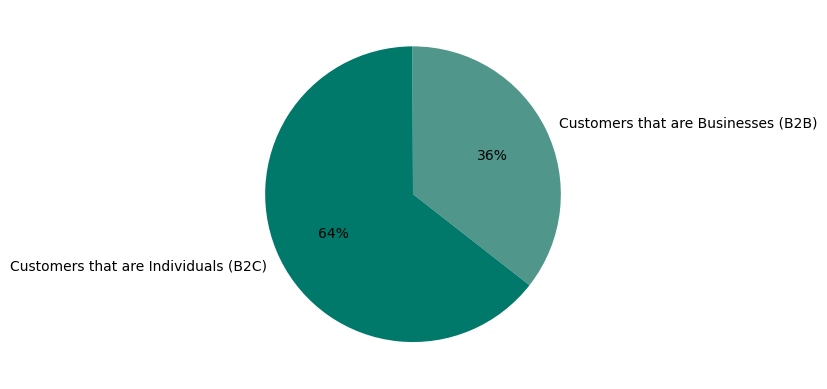

In [45]:
# Visualize the proportion of customers by type
import matplotlib.pyplot as plt

pie_chart = [3563, 6437]

plt.pie(
    pie_chart,
    labels=["Customers that are Businesses (B2B)", "Customers that are Individuals (B2C)"],
    colors=('#50968a', '#00796b'),
    autopct="%.0f%%",
    labeldistance=1.1,
    startangle= -38,
    normalize=True
)
plt.show()

These percentages in this visualization add to only 99% due to automatic rounding down of both values. The general trend is still evident, with roughly twice as many individual customers as customers that are businesses.

In [46]:
## Determine how many distinct order IDs exist in the dataset
con.sql("""
    SELECT
        COUNT(DISTINCT order_id) AS total_number_of_orders
    FROM star_beverage
""").df()

,total_number_of_orders
0,998709


In [47]:
## Determine how many order IDs exist for each customer type
con.sql("""
    SELECT
        c.customer_type,
        COUNT(DISTINCT f.order_id) AS total_orders
    FROM star_beverage AS f
    JOIN customer      AS c
      ON f.customer_key = c.customer_key
    GROUP BY c.customer_type
    ORDER BY total_orders DESC;
""").df()

,customer_type,total_orders
0,B2C,642953
1,B2B,355756


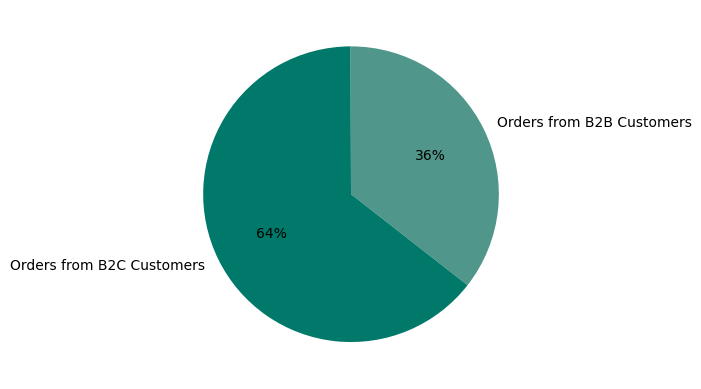

In [48]:
# Visualize the proportion of orders by customer type
import matplotlib.pyplot as plt

pie_chart = [355756, 642953]

plt.pie(
    pie_chart,
    labels=["Orders from B2B Customers", "Orders from B2C Customers"],
    colors=('#50968a', '#00796b'),
    autopct="%.0f%%",
    labeldistance=1.1,
    startangle= -38,
    normalize=True
)
plt.show()


These percentages in this visualization add to only 99% due to automatic rounding down of both values. The general trend is still evident, with roughly twice as many orders from individuals as from businesses.

In [49]:
# Determine total value of orders by customer type
con.sql("""
    SELECT
        c.customer_type,
        ROUND(SUM(f.total_price), 2) AS annual_spend
    FROM star_beverage AS f
    JOIN customer      AS c
      ON f.customer_key = c.customer_key
    GROUP BY c.customer_type
""").df()

,customer_type,annual_spend
0,B2C,9.394728e+07
1,B2B,3.078275e+08


In [50]:
## rank top B2B sales by Orders Placed (frequency)
con.sql("""
    SELECT
        c.customer_id AS customer,
        c.customer_type,
        COUNT(DISTINCT f.order_id) AS orders_placed,
        ROUND(SUM(f.total_price), 2) AS total_spend
    FROM star_beverage AS f
    JOIN customer      AS c
      ON f.customer_key = c.customer_key
    WHERE c.customer_type = 'B2B'
    GROUP BY c.customer_id, c.customer_type
    ORDER BY orders_placed DESC
    LIMIT 10;
""").df()

,customer,customer_type,orders_placed,total_spend
0,CUS4741,B2B,132,136895.93
1,CUS4882,B2B,131,81926.20
2,CUS7124,B2B,131,113868.57
3,CUS8679,B2B,130,101150.10
4,CUS6026,B2B,129,105042.97
5,CUS3051,B2B,129,138745.27
6,CUS5445,B2B,129,91129.18
7,CUS1890,B2B,129,140296.93
8,CUS1256,B2B,128,156826.63
9,CUS5225,B2B,128,99045.04


In [51]:
## rank top B2B sales by Total Price
con.sql("""
    SELECT
        c.customer_id AS customer,
        c.customer_type,
        ROUND(SUM(f.total_price), 2) AS total_spend,
        COUNT(DISTINCT f.order_id)   AS orders_placed
    FROM star_beverage AS f
    JOIN customer      AS c
      ON f.customer_key = c.customer_key
    WHERE c.customer_type = 'B2B'
    GROUP BY c.customer_id, c.customer_type
    ORDER BY total_spend DESC
    LIMIT 10;
""").df()

,customer,customer_type,total_spend,orders_placed
0,CUS7215,B2B,165817.79,124
1,CUS1256,B2B,156826.63,128
2,CUS3760,B2B,152836.67,114
3,CUS2662,B2B,152755.57,127
4,CUS9989,B2B,150458.40,118
5,CUS5646,B2B,149624.46,114
6,CUS1479,B2B,148456.91,115
7,CUS7309,B2B,147673.58,100
8,CUS8215,B2B,146498.96,115
9,CUS4511,B2B,141748.26,94


B2B customers in this dataset placed anywhere from 68 to 132 orders in 2023. (This can be found by sorting the above query by Orders Placed, both ascending and descending.) The top ten B2B customers by frequency have all placed 128 or more orders. However, when sorted by Total Price, we find that the largest orders by revenue come from B2B customers who have placed between 94-128 orders.

* All B2B customers are repeat customers, with at least 68 orders.
* The top 8 B2B customers by frequency (129+ orders) are not represented in the top 10 by revenue.
* The top 10 B2B customers are responsible for approximately 0.13% of all orders and approximately 0.36% of B2B orders in 2023 by frequency.

In [52]:
# create and preview df to create visualization: plot orders placed vs. total price
B2BSTP = con.sql("""
    SELECT
        c.customer_id        AS customer,
        c.customer_type      AS customer_type,
        ROUND(SUM(f.total_price), 2) AS total_price,
        COUNT(DISTINCT f.order_id)   AS orders_placed
    FROM star_beverage AS f
    JOIN customer      AS c
      ON f.customer_key = c.customer_key
    WHERE c.customer_type = 'B2B'
    GROUP BY c.customer_id, c.customer_type
    ORDER BY total_price DESC;
""").df()

B2BSTP.head()

,customer,customer_type,total_price,orders_placed
0,CUS7215,B2B,165817.79,124
1,CUS1256,B2B,156826.63,128
2,CUS3760,B2B,152836.67,114
3,CUS2662,B2B,152755.57,127
4,CUS9989,B2B,150458.40,118


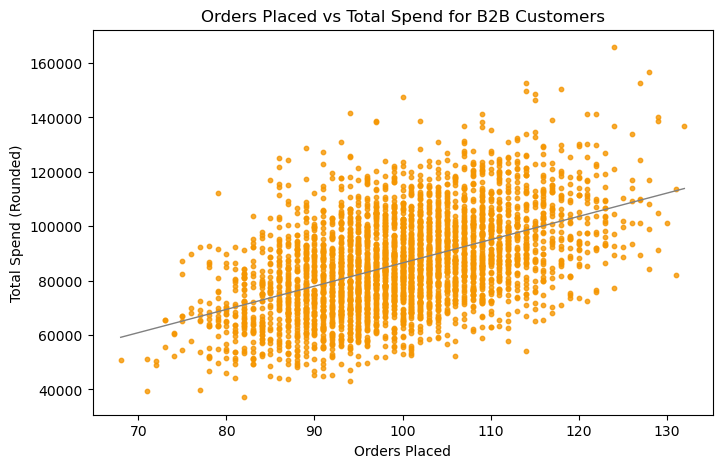

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# Fit a line: y = m*x + b
coefficients = np.polyfit(B2BSTP["orders_placed"], B2BSTP["total_price"], 1)
slope, intercept = coefficients

# Sequence of x values
xseq = np.linspace(B2BSTP["orders_placed"].min(), B2BSTP["orders_placed"].max(), 100)

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot
ax.scatter(
    B2BSTP["orders_placed"],
    B2BSTP["total_price"],
    s=10,
    c="#f59601",
    alpha=0.8
)
# Regression line
ax.plot(xseq, intercept + slope*xseq, color="gray", lw=1)

# Labels and title
ax.set_xlabel("Orders Placed")
ax.set_ylabel("Total Spend (Rounded)")
ax.set_title("Orders Placed vs Total Spend for B2B Customers")

plt.show()

In [54]:
# create df to plot B2B average spend per order
B2BASPO = con.sql("""
    SELECT
        "Customer_ID" AS Customer,
        "Customer_Type" AS "Customer Type",
        SUM("Total_Price") AS "Total Price",
        COUNT(DISTINCT "Order_ID") AS "orders_placed",
        ROUND(SUM("Total_Price") / COUNT(DISTINCT "Order_ID"), 2) AS "avg_spend_per_order"
    FROM beverage
    WHERE "Customer Type" = 'B2B'
    GROUP BY "Customer_ID", "Customer Type"
    ORDER BY "Total Price" DESC;
""").df()

B2BASPO.head()

,Customer,Customer Type,Total Price,orders_placed,avg_spend_per_order
0,CUS7215,B2B,165817.79,124,1337.24
1,CUS1256,B2B,156826.63,128,1225.21
2,CUS3760,B2B,152836.67,114,1340.67
3,CUS2662,B2B,152755.57,127,1202.80
4,CUS9989,B2B,150458.40,118,1275.07


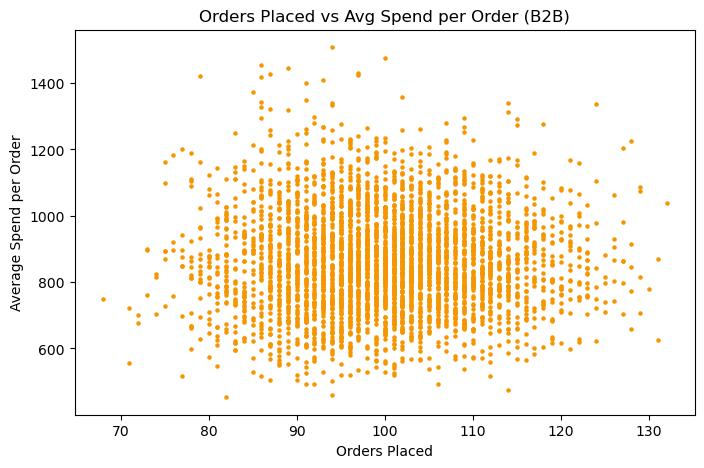

In [55]:
plt.figure(figsize=(8, 5))

plt.scatter(
    B2BASPO["orders_placed"],
    B2BASPO["avg_spend_per_order"],
    s=5,
    c="#f59601"
)

plt.xlabel("Orders Placed")
plt.ylabel("Average Spend per Order")
plt.title("Orders Placed vs Avg Spend per Order (B2B)")

plt.show()


### Key B2B Findings:
Among B2B sales, all customers are repeat customers. The B2B customer in this dataset with the fewest orders still placed 68 orders in 2023. That is more than one order per week. When plotting the number of orders placed by the customer versus their total spend, there appears to be relatively strong correlation between the two variables. However, when plotting the average spend per order there is no clear trend line, indicating low or no correlation between the amount spent on each order for those who B2B customers who place more orders.

### Among B2C sales, are larger orders from repeat customers?

In [56]:
### rank top B2C sales by Total Price
con.sql("""
    SELECT
        "Customer_ID" AS "Customer",
        "Customer_Type",
        ROUND(SUM("Total_Price"),2) as "Total Price",
        COUNT (DISTINCT("Order_ID")) AS "Orders Placed"
    FROM beverage
    WHERE
        "Customer_Type" = 'B2C'
    GROUP BY
        "Customer_ID", "Customer_Type"
    ORDER BY "Total Price" DESC
    LIMIT 10;
""").df()

,Customer,Customer_Type,Total Price,Orders Placed
0,CUS9683,B2C,27978.68,121
1,CUS3644,B2C,26497.33,111
2,CUS421,B2C,26098.68,114
3,CUS1765,B2C,25690.19,117
4,CUS789,B2C,25662.86,113
5,CUS6034,B2C,25104.73,117
6,CUS168,B2C,25103.73,120
7,CUS4186,B2C,24962.49,106
8,CUS7214,B2C,24910.10,113
9,CUS4735,B2C,24522.65,116


In [57]:
# number of orders placed divided by total number of orders, all customer types
con.sql("""
    SELECT ((135 + 133*3 + 132*3 + 131*3) / 998709.0 * 100)
        AS percent_of_all_orders;
""").df()

,percent_of_all_orders
0,0.132471


In [58]:
# number of orders placed divided by total number of orders, B2B customers
con.sql("""
    SELECT ((135+133*3+132*3+131*3)/642953*100)
        AS pecent_of_B2B_orders
""").df()

,pecent_of_B2B_orders
0,0.205769


In [59]:
## rank top B2C sales by Orders Placed (frequency)
con.sql("""
SELECT
    c.customer_id                  AS customer,
    c.customer_type                AS customer_type,
    COUNT(DISTINCT f.order_id)     AS orders_placed,
    ROUND(SUM(f.total_price),2)            AS total_price
FROM star_beverage AS f
JOIN customer      AS c
  ON f.customer_key = c.customer_key
WHERE c.customer_type = 'B2C'
GROUP BY
    c.customer_id,
    c.customer_type
ORDER BY
    orders_placed DESC
LIMIT 10;
""").df()

,customer,customer_type,orders_placed,total_price
0,CUS5026,B2C,135,23589.72
1,CUS9019,B2C,133,16139.15
2,CUS7562,B2C,133,21157.33
3,CUS8810,B2C,133,22824.68
4,CUS6282,B2C,132,14841.11
5,CUS4419,B2C,132,15383.01
6,CUS5638,B2C,132,18336.39
7,CUS9660,B2C,131,21012.93
8,CUS288,B2C,131,17112.13
9,CUS6456,B2C,131,16400.47


In [60]:
## rank top B2C sales by Total Price
con.sql("""
SELECT
    c.customer_id              AS customer,
    c.customer_type            AS customer_type,
    SUM(f.total_price)         AS total_price,
    COUNT(DISTINCT f.order_id) AS orders_placed
FROM star_beverage AS f
JOIN customer      AS c
  ON f.customer_key = c.customer_key
WHERE c.customer_type = 'B2C'
GROUP BY
    c.customer_id,
    c.customer_type
ORDER BY
    total_price DESC
LIMIT 10;
""").df()

,customer,customer_type,total_price,orders_placed
0,CUS9683,B2C,27978.68,121
1,CUS3644,B2C,26497.33,111
2,CUS421,B2C,26098.68,114
3,CUS1765,B2C,25690.19,117
4,CUS789,B2C,25662.86,113
5,CUS6034,B2C,25104.73,117
6,CUS168,B2C,25103.73,120
7,CUS4186,B2C,24962.49,106
8,CUS7214,B2C,24910.10,113
9,CUS4735,B2C,24522.65,116


B2C customers in this dataset placed anywhere from 62 to 135 orders in 2023. (This can be found by sorting the above query by Orders Placed, both ascending and descending.) The top ten B2C customers by frequency have all placed 131 or more orders. However, when sorted by Total Price, we find that the largest orders by revenue come from B2C customers who have placed between 111-121 orders.

* All B2C customers are repeat customers, with at least 62 orders.
* The top 10 B2C customers by frequency (131+ orders) are not represented in the top 10 by revenue.
* The top 10 B2C customers are responsible for approximately 13.24% of all orders and approximately 20.57% of B2C orders in 2023 by frequency.

In [61]:
# create df to plot orders placed vs. total price
B2CSTP = con.sql("""
    SELECT
        c.customer_id              AS customer,
        c.customer_type            AS customer_type,
        SUM(f.total_price)         AS total_price,
        COUNT(DISTINCT f.order_id) AS orders_placed
    FROM star_beverage AS f
    JOIN customer      AS c
      ON f.customer_key = c.customer_key
    WHERE c.customer_type = 'B2C'
    GROUP BY
        c.customer_id,
        c.customer_type
    ORDER BY total_price DESC;
""").df()

B2CSTP.head()

,customer,customer_type,total_price,orders_placed
0,CUS9683,B2C,27978.68,121
1,CUS3644,B2C,26497.33,111
2,CUS421,B2C,26098.68,114
3,CUS1765,B2C,25690.19,117
4,CUS789,B2C,25662.86,113


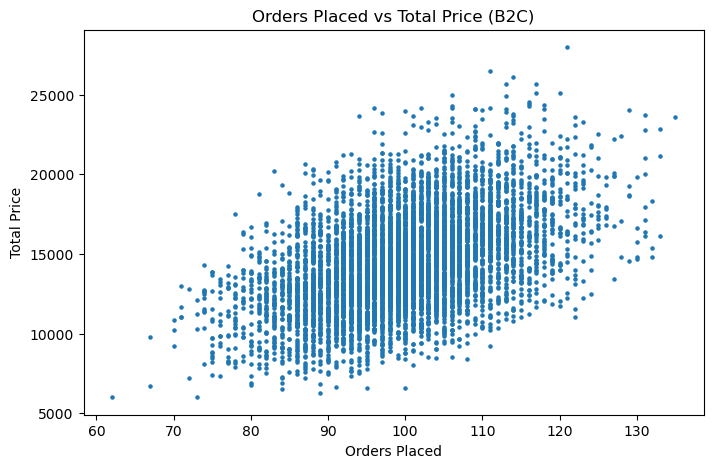

In [62]:
# create visualization of orders placed vs. total price
plt.figure(figsize=(8, 5))

plt.scatter(
    B2CSTP["orders_placed"],
    B2CSTP["total_price"],
    s=5  # this makes the dots in the scatterplot smaller
)

plt.xlabel("Orders Placed")
plt.ylabel("Total Price")
plt.title("Orders Placed vs Total Price (B2C)")

plt.show()

In [63]:
# create df to plot orders placed vs. average spend
B2CASPO = con.sql("""
    SELECT
        c.customer_id              AS customer,
        c.customer_type            AS customer_type,
        SUM(f.total_price)         AS total_price,
        COUNT(DISTINCT f.order_id) AS orders_placed,
        ROUND(SUM(f.total_price) / COUNT(DISTINCT f.order_id), 2) AS avg_spend_per_order
    FROM star_beverage AS f
    JOIN customer      AS c
      ON f.customer_key = c.customer_key
    WHERE c.customer_type = 'B2C'
    GROUP BY
        c.customer_id,
        c.customer_type
    ORDER BY total_price DESC;
""").df()

B2CASPO.head()

,customer,customer_type,total_price,orders_placed,avg_spend_per_order
0,CUS9683,B2C,27978.68,121,231.23
1,CUS3644,B2C,26497.33,111,238.71
2,CUS421,B2C,26098.68,114,228.94
3,CUS1765,B2C,25690.19,117,219.57
4,CUS789,B2C,25662.86,113,227.10


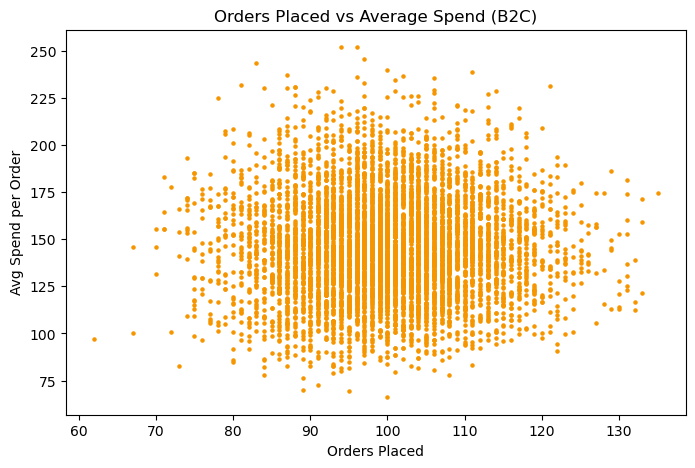

In [64]:
# create visualization of orders placed vs. average spend
plt.figure(figsize=(8, 5))

plt.scatter(
    B2CASPO["orders_placed"],
    B2CASPO["avg_spend_per_order"],
    s=5, #this makes the dots in the scatterplot smaller
    c="#f59601" # this selects the specific color to match the slide deck
)

plt.xlabel("Orders Placed")
plt.ylabel("Avg Spend per Order")
plt.title("Orders Placed vs Average Spend (B2C)")

plt.show()

### Key B2C Findings:
Among B2C sales, all customers are repeat customers. The B2C customer in this dataset with the fewest orders still placed 62 orders in 2023 - more than one order per week. When plotting the number of orders placed by the customer versus their total spend, there appears to be relatively strong correlation between the two variables. However, when plotting the average spend per order there is no clear trend line, indicating low or no correlation between the amount spent on each order for those who B2C customers who place more orders. This is substantially similar to our findings for the B2B customers, other than the average spend per order. It makes sense that Businesses would be placing orders of 1000 euros while Individuals are placing orders of around 150 euros.

### B2B and B2C Findings:
Overall, this data does not strongly support any specific pricing or promotional change for either segment. However, since total revenue is driven by repeat purchasing rather than by larger individual orders, the recommendation for the client would be to continue to nurture and retain the repeat customers, as this would likely yield more revenue for the company.